In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, norm
from empiricaldist import Pmf
from utils import decorate

sns.set_style('darkgrid')

## 9.2 The Prior

In [2]:
def read_data(filename):
    """Read the showcase price data."""
    df = pd.read_csv(filename, index_col=0, skiprows=[1])
    return df.dropna().transpose()

In [3]:
df2011 = read_data('./data/showcases.2011.csv')
df2012 = read_data('./data/showcases.2012.csv')

df = pd.concat([df2011, df2012], ignore_index=True)
df.head(3)

,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0


## 9.3 Kernel Density Estimation

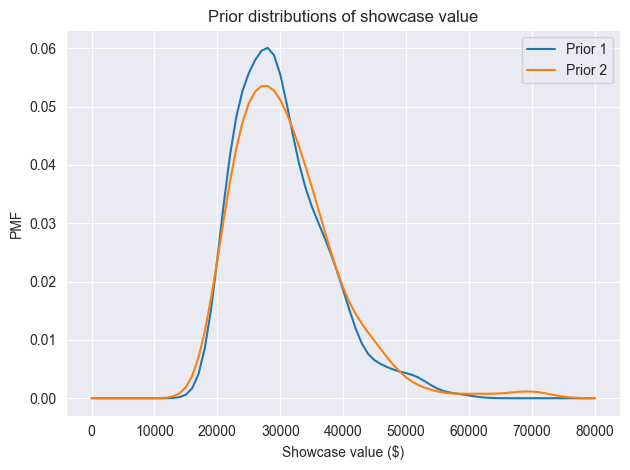

In [4]:
def kde_from_sample(sample, qs):
    """Make a kernel density estimate from a sample."""
    kde = gaussian_kde(sample)
    ps = kde(qs)
    pmf = Pmf(ps, qs)
    pmf.normalize()
    return pmf


def decorate_value(title=''):
    decorate(
        xlabel='Showcase value ($)',
        ylabel='PMF',
        title=title
    )
    

qs = np.linspace(0, 80000, 81)
price_prior1 = kde_from_sample(df['Showcase 1'], qs)
price_prior2 = kde_from_sample(df['Showcase 2'], qs)

price_prior1.plot(label='Prior 1')
price_prior2.plot(label='Prior 2')
decorate_value('Prior distributions of showcase value')

## 9.4 Distribution of Error

In [5]:
diff_sample1 = df['Bid 1'] - df['Showcase 1']

diff_mean1 = diff_sample1.mean()
diff_std1 = diff_sample1.std()

print(diff_mean1, diff_std1)
error_dist1 = norm(0, diff_std1)

-4116.3961661341855 6899.909806377117


In [6]:
diff_sample2 = df['Bid 2'] - df['Showcase 2']

diff_mean2 = diff_sample2.mean()
diff_std2 = diff_sample2.std()

print(diff_mean2, diff_std2)
error_dist2 = norm(0, diff_std2)

-3675.891373801917 6886.260711323408


## 9.5 Update

(30299.488817891375, 26192.024002392536)

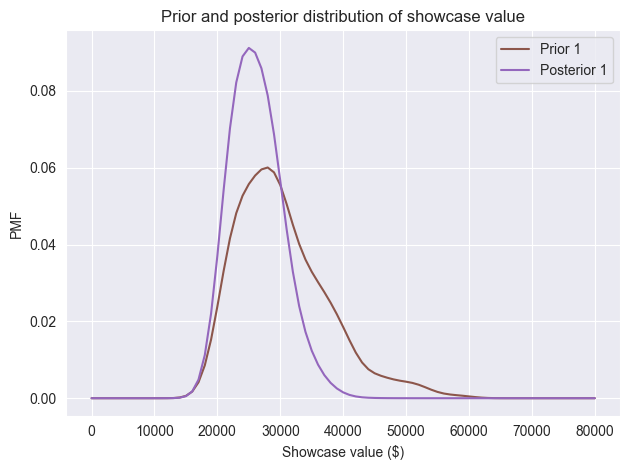

In [7]:
guess1 = 23000
error1 = guess1 - price_prior1.qs
likelihood1 = error_dist1.pdf(error1)

price_posterior1 = price_prior1 * likelihood1
price_posterior1.normalize()

price_prior1.plot(color='C5', label='Prior 1')
price_posterior1.plot(color='C4', label='Posterior 1')
decorate_value('Prior and posterior distribution of showcase value')

price_prior1.mean(), price_posterior1.mean()

(31047.623719122505, 34305.20161642469)

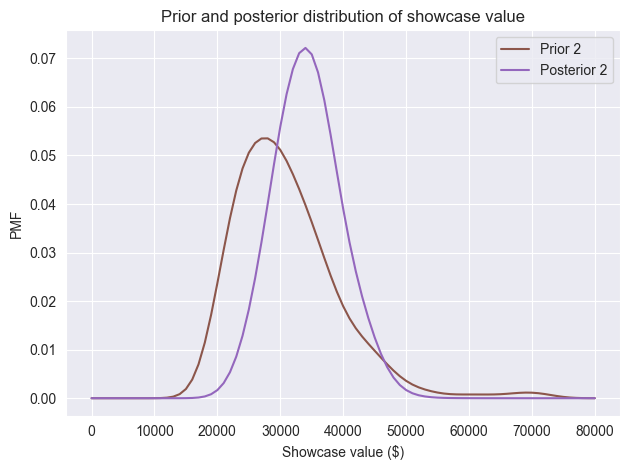

In [8]:
guess2 = 38000
error2 = guess2 - price_prior2.qs
likelihood2 = error_dist2.pdf(error2)

price_posterior2 = price_prior2 * likelihood2
price_posterior2.normalize()
price_prior2.plot(color='C5', label='Prior 2')
price_posterior2.plot(color='C4', label='Posterior 2')
decorate_value('Prior and posterior distribution of showcase value')

price_prior2.mean(), price_posterior2.mean()

## 9.6. Probability of Winning

In [9]:
def calc_overbid_prob(diff_sample):
    """Compute the probability of an overbid."""
    return np.mean(diff_sample > 0)


print(f"Probability of player 2 overbidding: {calc_overbid_prob(diff_sample2)}")

Probability of player 2 overbidding: 0.29073482428115016


In [10]:
def calc_worse_than_prob(diff_sample, threshold):
    """Probability diff is worse than threshold."""
    return np.mean(diff_sample < threshold)


print(f"Probability of player 2 diff worse than -5000: {calc_worse_than_prob(diff_sample2, -5000)}")
print(f"Probability of player 2 diff worse than -10000: {calc_worse_than_prob(diff_sample2, -10000)}")

Probability of player 2 diff worse than -5000: 0.38338658146964855
Probability of player 2 diff worse than -10000: 0.14376996805111822


In [11]:
def calc_conditional_win_prob(diff, opponent_diff_sample):
    """Probability of winning for a given diff."""
    # if you overbid you lose
    if diff > 0:
        return 0
    
    # if the opponent overbids, you win
    opponent_overbid_prob = calc_overbid_prob(opponent_diff_sample)
    
    # or of their bid is worse than yours, you win
    opponent_worse_prob = calc_worse_than_prob(opponent_diff_sample, diff)
    
    # p1 and p2 are mutually exclusive, so we can add them
    return opponent_overbid_prob + opponent_worse_prob


prob_win1 = calc_conditional_win_prob(-5000, diff_sample2)
print(f"Probability of player 1 winning with a diff of -5000: {prob_win1:.2%}")

Probability of player 1 winning with a diff of -5000: 67.41%


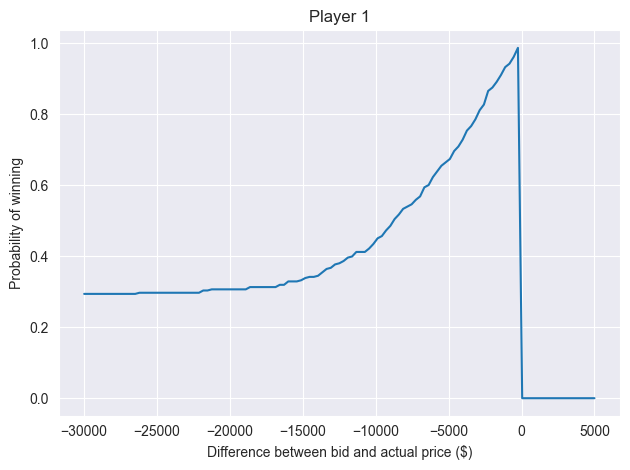

In [12]:
xs = np.linspace(-30000, 5000, 121)
ys = [calc_conditional_win_prob(x, diff_sample2) for x in xs]

plt.plot(xs, ys)
decorate(
    xlabel='Difference between bid and actual price ($)',
    ylabel='Probability of winning',
    title='Player 1'
)

In [13]:
print(f"Probability of player 1 overbidding: {calc_overbid_prob(diff_sample1)}")
print(f"Probability of player 1 diff worse than -5000: {calc_worse_than_prob(diff_sample1, -5000)}")
print(f"Probability of player 2 winning with -5000 diff: {calc_conditional_win_prob(-5000, diff_sample1)}")

Probability of player 1 overbidding: 0.24600638977635783
Probability of player 1 diff worse than -5000: 0.3993610223642173
Probability of player 2 winning with -5000 diff: 0.6453674121405751


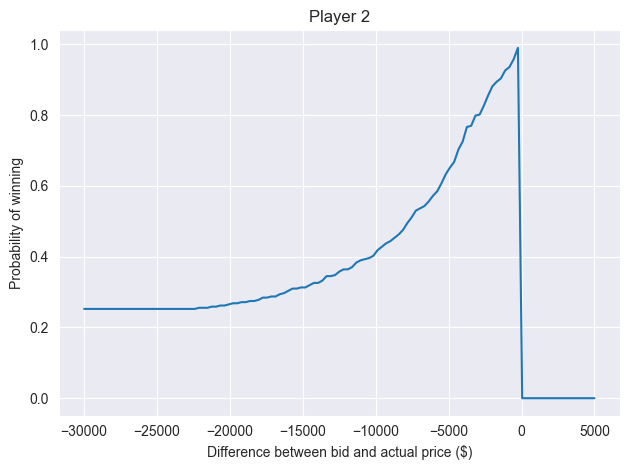

In [14]:
xs = np.linspace(-30000, 5000, 121)
ys = [calc_conditional_win_prob(x, diff_sample1) for x in xs]

plt.plot(xs, ys)
decorate(
    xlabel='Difference between bid and actual price ($)',
    ylabel='Probability of winning',
    title='Player 2'
)

## 9.7 Decision Analysis

(21000.0, 0.6136807192359474)

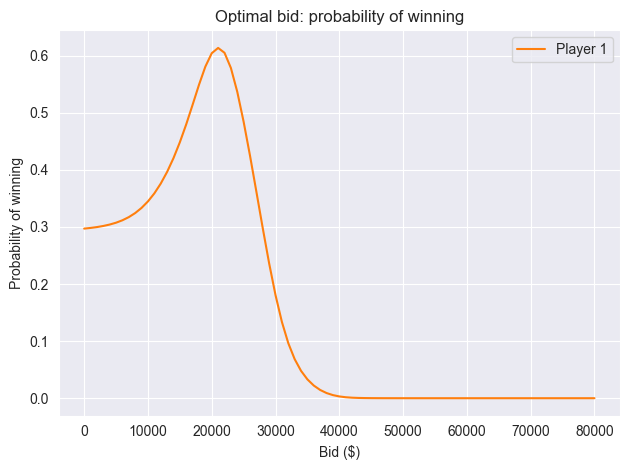

In [ ]:
def calc_total_win_prob(bid, price_posterior, opponent_diff_sample):
    """Computes the total probability of winning with a given bid.

    bid: your bid
    posterior: Pmf of showcase value
    sample_diff: sequence of differences for the opponent
    
    returns: probability of winning
    """
    total = 0
    for price, price_prob in price_posterior.items():
        diff = bid - price
        total += (
            price_prob 
            * calc_conditional_win_prob(diff, opponent_diff_sample)
        )
    return total


prob_win1 = [
    calc_total_win_prob(bid, price_posterior1, diff_sample2) 
    for bid in price_posterior1.qs
]
prob_win1 = pd.Series(prob_win1, index=price_posterior1.qs)

prob_win1.plot(label='Player 1', color='C1')
decorate(
    xlabel='Bid ($)',
    ylabel='Probability of winning',
    title='Optimal bid: probability of winning'
)
prob_win1.idxmax(), prob_win1.max()

(29000.0, 0.5171370053364229)

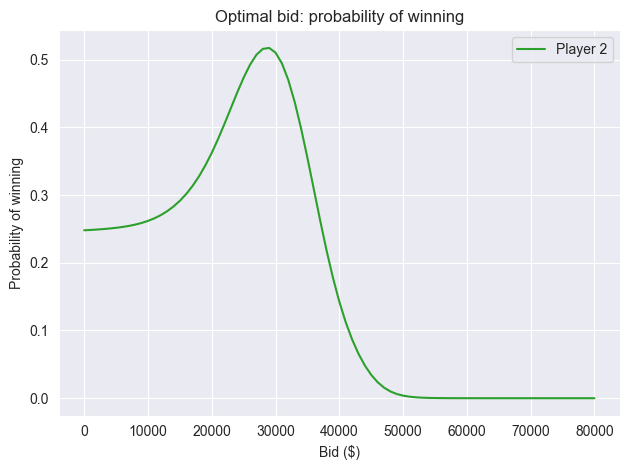

In [16]:
prob_win2 = [
    calc_total_win_prob(bid, price_posterior2, diff_sample1) 
    for bid in price_posterior2.qs
]
prob_win2 = pd.Series(prob_win2, index=price_posterior2.qs)

prob_win2.plot(label='Player 2', color='C2')
decorate(
    xlabel='Bid ($)',
    ylabel='Probability of winning',
    title='Optimal bid: probability of winning'
)
prob_win2.idxmax(), prob_win2.max()

## 9.8. Maximizing Expected Gain

In [17]:
def calc_conditional_gain(bid, price, opponent_diff_sample):
    """Compute expected gain given a bid and actual price."""
    diff = bid - price
    conditional_win_prob = calc_conditional_win_prob(diff, opponent_diff_sample)

    # if you are within 250 dollars, you win both showcases
    if -250 <= diff <= 0:
        return 2 * price * conditional_win_prob
    else:
        return price * conditional_win_prob
    
    
calc_conditional_gain(30000, 35000, diff_sample2)

23594.249201277955

In [18]:
def calc_expected_gain(bid, price_posterior, opponent_diff_sample):
    """Compute the expected gain of a given bid."""
    expected_gain = 0
    for price, price_prob in price_posterior.items():
        expected_gain += (
            price_prob 
            * calc_conditional_gain(bid, price, opponent_diff_sample)
        )
    return expected_gain


calc_expected_gain(21000, price_posterior1, diff_sample2)

16923.59933856512

(22000.0, 17384.899584430797)

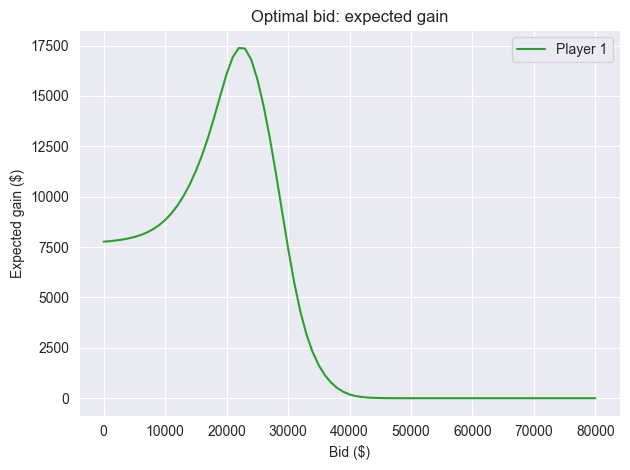

In [20]:
expected_gains1 = [
    calc_expected_gain(bid, price_posterior1, diff_sample2) 
    for bid in price_posterior1.qs
]
expected_gains1 = pd.Series(expected_gains1, index=price_posterior1.qs)

expected_gains1.plot(label='Player 1', color='C2')
decorate(
    xlabel='Bid ($)',
    ylabel='Expected gain ($)',
    title='Optimal bid: expected gain'
)

expected_gains1.idxmax(), expected_gains1.max()

(30000.0, 19404.164188501607)

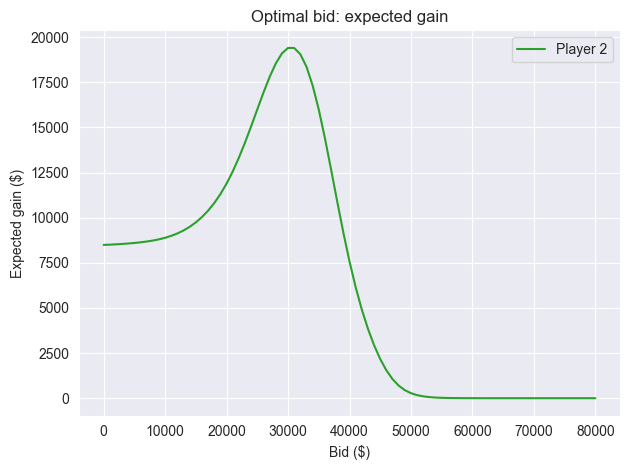

In [21]:
expected_gains2 = [
    calc_expected_gain(bid, price_posterior2, diff_sample1) 
    for bid in price_posterior2.qs
]
expected_gains2 = pd.Series(expected_gains2, index=price_posterior2.qs)

expected_gains2.plot(label='Player 2', color='C2')
decorate(
    xlabel='Bid ($)',
    ylabel='Expected gain ($)',
    title='Optimal bid: expected gain'
)

expected_gains2.idxmax(), expected_gains2.max()